In [1]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [4]:
data = pd.read_csv(current_directory+"/data_model.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [5]:
data_test = data.sample(n=6, random_state=42)

In [6]:
data_test.head()

,full_sq,life_sq,floor,num_room,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,...,cafe_count_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_avg,cafe_avg_price_2000,cafe_count_2000_na_price,cafe_count_2000_price_500,cafe_count_2000_price_1000,cafe_count_2000_price_1500,cafe_count_2000_price_2500,cafe_

In [7]:
target_cols =["price_doc", "price_doc_log","price_per_m2","log_price_per_m2"]
other_cols = [c for c in data.columns if c not in target_cols]

In [8]:
y_test = data[target_cols]
X_test = data[other_cols]

In [9]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

In [10]:
def return_train_test(df_,  targets, target_col = "price_doc_log",):

    df_sorted = df_.copy()
    df_sorted["year_month"] = df_sorted["year"] * 100 + df_sorted["month"]

    df_sorted = df_sorted.sort_values("year_month")

    y = df_sorted[target_col]
    X = df_sorted.drop(columns=targets)
    
    split_idx = int(len(df_sorted) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [11]:
def unlog(x):
    return np.expm1(x) 

In [12]:
data_test["year_month"] = data_test["year"] * 100 + data_test["month"]

In [13]:
stack_pipeline = joblib.load("stack_pipeline.pkl")

In [14]:
y_pred_log = stack_pipeline.predict(data_test)

In [15]:
y_test = unlog(data_test["price_doc_log"])
y_pred = np.round(unlog(y_pred_log),2)

In [16]:
results_df = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred
})

results_df

,y_test,y_pred
8223,12300000.0,12252109.01
20582,6000000.0,5872894.10
26346,24000000.0,13050124.65
6173,1200000.0,4280942.62
18568,6289920.0,6468341.65
11985,6341036.0,5936595.09


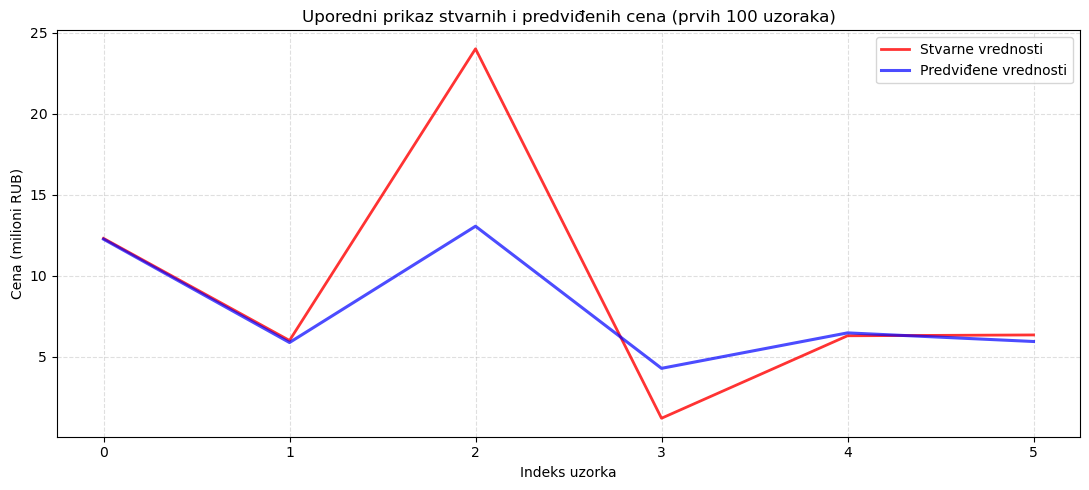

In [17]:
from matplotlib.ticker import MaxNLocator

y_true_sample = y_test / 1_000_000
y_pred_sample = y_pred / 1_000_000

plt.figure(figsize=(11, 5))
plt.plot(y_true_sample.values, color="red", linewidth=2, label="Stvarne vrednosti", alpha=0.8)
plt.plot(y_pred_sample, color="blue", linewidth=2.2, label="Predviđene vrednosti", alpha=0.7)

plt.title("Uporedni prikaz stvarnih i predviđenih cena (prvih 100 uzoraka)")
plt.xlabel("Indeks uzorka")
plt.ylabel("Cena (milioni RUB)")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()